## 1. 配置

In [ ]:
RAW_PATH   = 'D:/investment/Data/hs300_factor_data_filled.parquet'
PANEL_PATH = 'D:/investment/Data/factor_panel_v2_processed.parquet'
IC_PATH    = 'D:/investment/Data/03v3_ic_summary.csv'

IC_TSTAT_THRESHOLD = 2.0
MIN_COVERAGE       = 0.70
FWD_RET_COVERAGE   = 0.80
HIDDEN_DIM = 32
SEED       = 42

N_WARM     = 10
N_E2E      = 60
LR_MSE     = 1e-3
LR_E2E     = 1e-4
GRAD_CLIP  = 1.0
BATCH_SIZE = 8

# ── 风险偏好（论文 Eq.21 里的 eta）───────────────────────────────────────
LAMBDA      = 1.0
LAMBDA_LIST = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# ── 平滑参数（技术项，不改变经济目标）────────────────────────────────────
# ZETA_TRAIN: 内层 QP 的 L2 平滑，保证解映射更稳定
# EPS_TC    : 把 |x| 平滑成 sqrt(x^2 + eps)，保证 TC 项可微
ZETA_TRAIN = 10.0
EPS_TC     = 1e-4
ALPHA_IC   = 0.05

# ── 交易成本参数（论文 Eq.21 里的 gamma）────────────────────────────────
# 重要：论文口径是 (GAMMA / 2) * ||w_t - w_{t-1}||_1
# 因为 ||Δw||_1 是双边 turnover，所以这里千万不要直接用 GAMMA * ||Δw||_1
GAMMA      = 0.003
TC_RATE    = GAMMA   # 兼容原 notebook 命名；实际使用时统一走 0.5 * GAMMA * L1

MAX_W_FRAC = 10
TRAIN_WINDOW = 36
STEP_SIZE    = 3

print("="*72)
print("E2E v5c — Section 4.4 / Eq.(21) aligned notebook")
print("="*72)
print(f"LAMBDA      = {LAMBDA}   (risk aversion eta)")
print(f"GAMMA       = {GAMMA}   (paper gamma / TCR)")
print(f"ZETA_TRAIN  = {ZETA_TRAIN}   (technical L2 smoothing)")
print(f"EPS_TC      = {EPS_TC}   (smooth |x| -> sqrt(x^2+eps))")
print(f"ALPHA_IC    = {ALPHA_IC}")
print()
print("Inner problem : -mu^T w + 0.5*gamma*||w-w_prev||_1 + lambda*sqrt(w^T D w) + 0.5*zeta*||w||^2")
print("Outer loss    : -(w^T r - 0.5*gamma*||w-w_prev||_1 - lambda*sqrt(w^T D w))")


E2E v5c — Section 4.4 / Eq.(21) aligned notebook
LAMBDA      = 1.0   (risk aversion eta)
GAMMA       = 0.003   (paper gamma / TCR)
ZETA_TRAIN  = 10.0   (technical L2 smoothing)
EPS_TC      = 0.0001   (smooth |x| -> sqrt(x^2+eps))
ALPHA_IC    = 0.05

Inner problem : -mu^T w + 0.5*gamma*||w-w_prev||_1 + lambda*sqrt(w^T D w) + 0.5*zeta*||w||^2
Outer loss    : -(w^T r - 0.5*gamma*||w-w_prev||_1 - lambda*sqrt(w^T D w))


## 2. 导入与数据加载

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings, time
from collections import Counter
from scipy.optimize import brentq
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F

torch.manual_seed(SEED); np.random.seed(SEED)
plt.rcParams['font.sans-serif'] = ['SimHei','Arial Unicode MS','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

panel = pd.read_parquet(PANEL_PATH)
panel['date'] = pd.to_datetime(panel['date'])
ic_df = pd.read_csv(IC_PATH, index_col=0)
if 'Sig(|t|>2)' in ic_df.columns:    sig_mask = ic_df['Sig(|t|>2)']
elif 't_stat' in ic_df.columns:       sig_mask = ic_df['t_stat'].abs() > IC_TSTAT_THRESHOLD
else: raise ValueError("IC 文件需含 t_stat 或 Sig(|t|>2) 列")
SIG_FACTORS = list(ic_df[sig_mask].index); N_FEATURES = len(SIG_FACTORS)
print(f"Factor panel: {panel.shape}  ({panel['date'].nunique()} months)")
print(f"显著因子 ({N_FEATURES} 个): {SIG_FACTORS}")
assert N_FEATURES >= 2

Factor panel: (21760, 105)  (68 months)
显著因子 (10 个): ['F91_ocf_ni', 'F97_accruals', 'F80_ocf_mv', 'F74_cfp', 'F55_holding_adj', 'F81_size', 'F34_vol_of_vol', 'F88_cash_roe', 'F41_turn_std', 'F30_range_vol']


## 3. 股票池 & 特征

In [3]:
all_dates = sorted(panel['date'].unique())
def get_valid_stocks(df, factors):
    return set(df.dropna(subset=factors + ['fwd_ret'])['ts_code'].unique())
month_valid = {d: get_valid_stocks(panel[panel['date']==d], SIG_FACTORS) for d in all_dates}
stock_cnt = Counter(s for v in month_valid.values() for s in v)
universe  = sorted(s for s,c in stock_cnt.items() if c/len(all_dates) >= MIN_COVERAGE)
N = len(universe); MAX_W = MAX_W_FRAC / N

panel_u = (panel[panel['ts_code'].isin(universe)].sort_values(['date','ts_code']).reset_index(drop=True))
for col in SIG_FACTORS:
    panel_u[col] = panel_u.groupby('date')[col].transform(
        lambda x: x.fillna(0 if x.isna().all() else x.mean()))
panel_u['fwd_ret'] = panel_u.groupby('date')['fwd_ret'].transform(
    lambda x: x.fillna(x.median() if not x.isna().all() else 0))
def cross_sec_zscore(arr):
    mu = arr.mean(0,keepdims=True); sig = np.maximum(arr.std(0,keepdims=True),1e-8)
    return np.nan_to_num((arr-mu)/sig).astype('float32')
fwd_cov = panel_u.groupby('date')['fwd_ret'].apply(lambda x: x.notna().mean())
dates_valid = [d for d in sorted(panel_u['date'].unique()) if fwd_cov.get(d,0) >= FWD_RET_COVERAGE]
X_tensors, y_tensors = [], []
for d in dates_valid:
    sub = panel_u[panel_u['date']==d].sort_values('ts_code')
    X_tensors.append(torch.tensor(cross_sec_zscore(sub[SIG_FACTORS].values)))
    y_tensors.append(torch.tensor(sub['fwd_ret'].values.astype('float32')))
T = len(X_tensors)
print(f"股票池: {N} 只   max_w = {MAX_W_FRAC}/N = {MAX_W:.4f}  有效月份: {T}")

股票池: 252 只   max_w = 10/N = 0.0397  有效月份: 68


## 4. 滚动窗口

In [4]:
rolling_windows = []
start = 0
while start + TRAIN_WINDOW + STEP_SIZE <= T:
    rolling_windows.append({'train_start':start,'train_end':start+TRAIN_WINDOW,
                             'test_start':start+TRAIN_WINDOW,
                             'test_end':min(start+TRAIN_WINDOW+STEP_SIZE,T)})
    start += STEP_SIZE
assert rolling_windows
fw, lw = rolling_windows[0], rolling_windows[-1]
print(f"滚动窗口: {len(rolling_windows)} 个")
print(f"首: [{dates_valid[fw['train_start']].date()}~{dates_valid[fw['train_end']-1].date()}] → [{dates_valid[fw['test_start']].date()}~{dates_valid[fw['test_end']-1].date()}]")
print(f"末: 测试 [{dates_valid[lw['test_start']].date()}~{dates_valid[lw['test_end']-1].date()}]")

滚动窗口: 10 个
首: [2020-04-30~2023-03-31] → [2023-04-28~2023-06-30]
末: 测试 [2025-07-31~2025-09-30]


## 5. 可微 SOCP + TC 层（v5c）

内层与论文 Eq.(21) 对齐，只是在实现上把

\[
\|w-w_{t-1}\|_1
\]

平滑为

\[
\sum_i \sqrt{(w_i-w_{i,t-1})^2+\varepsilon_{\text{tc}}}.
\]

因此训练时优化的是：

\[
\min_w\;
-\mu^\top w
+\frac{\gamma}{2}\sum_i \sqrt{(w_i-w_{i,t-1})^2+\varepsilon_{\text{tc}}}
+\lambda\sqrt{w^\top Dw}
+\frac{\zeta}{2}\|w\|^2
\]

subject to \(w\ge 0,\; \mathbf 1^\top w=1,\; w\le 10/N\).


In [5]:
import numpy as np, torch, torch.nn as nn
from scipy.optimize import brentq

def smooth_l1_value_np(delta, eps):
    return np.sqrt(delta**2 + eps).sum()

def smooth_l1_grad_vec(delta, eps):
    return delta / np.sqrt(delta**2 + eps)

def smooth_l1_hess_diag(delta, eps):
    return eps / (delta**2 + eps)**1.5

def smooth_l1_value_torch(delta, eps):
    return torch.sqrt(delta.pow(2) + eps).sum()

def turnover_l1_np(w, w_prev):
    return np.abs(w - w_prev).sum()

def turnover_l1_torch(w, w_prev):
    return (w - w_prev).abs().sum()


def solve_socp_tc(mu_np, var_np, w_prev_np, lambda_, gamma, max_w, zeta,
                  eps_tc=1e-4, max_outer=30, max_inner=50, tol=1e-10):
    """
    Solve the smoothed Eq.(21) inner problem under diagonal covariance:

        min_w  -mu^T w
               + 0.5*gamma*sum_i sqrt((w_i-wprev_i)^2 + eps_tc)
               + lambda*sqrt(w^T D w)
               + 0.5*zeta*||w||^2
        s.t.   sum(w)=1, 0<=w<=max_w

    Strategy:
      - outer loop linearizes the TC term at current iterate
      - inner loop solves the resulting diagonal-risk SOCP by fixed point on P = sqrt(w^T D w)

    This stays close to the notebook's existing SOCP design and keeps the implementation stable.
    """
    n = len(mu_np)

    # Initial point: solve the zeta-smoothed LP, centered around mu only.
    z0 = max(zeta, 1e-6)
    def init_budget(nu):
        return np.clip((mu_np - nu) / z0, 0, max_w).sum() - 1.0

    try:
        nu0 = brentq(init_budget, mu_np.min() - max_w * z0 - 1.0, mu_np.max() + 1.0,
                     xtol=1e-12, maxiter=300)
        w = np.clip((mu_np - nu0) / z0, 0, max_w)
        s = w.sum()
        w = w / s if s > 1e-12 else np.ones(n) / n
    except Exception:
        w = np.ones(n) / n

    P = max(np.sqrt((w**2 * var_np).sum()), 1e-8)

    for _ in range(max_outer):
        delta = w - w_prev_np
        tc_grad = 0.5 * gamma * smooth_l1_grad_vec(delta, eps_tc)
        mu_eff = mu_np - tc_grad

        w_new, P_new = w.copy(), P
        for _ in range(max_inner):
            eff_z = lambda_ * var_np / P_new + zeta

            def budget(nu):
                return np.clip((mu_eff - nu) / eff_z, 0, max_w).sum() - 1.0

            nu_lo = (mu_eff - eff_z * max_w).max() - 1.0
            nu_hi = mu_eff.max() + 1.0

            try:
                nu = brentq(budget, nu_lo, nu_hi, xtol=1e-12, maxiter=400)
                w_try = np.clip((mu_eff - nu) / eff_z, 0, max_w)
                s = w_try.sum()
                w_try = w_try / s if s > 1e-12 else np.ones(n) / n
            except Exception:
                break

            P_try = max(np.sqrt((w_try**2 * var_np).sum()), 1e-8)
            if abs(P_try - P_new) < tol:
                w_new, P_new = w_try, P_try
                break
            w_new, P_new = w_try, P_try

        if np.max(np.abs(w_new - w)) < tol:
            w, P = w_new, P_new
            break
        w, P = w_new, P_new

    return w, P


class SOCPTCFunction(torch.autograd.Function):
    """
    Forward :
        solve_socp_tc

    Backward :
        implicit differentiation on the free set F.

    For free variables, the diagonal part of the Hessian is

        h_i = lambda * var_i / P
              + zeta
              + 0.5 * gamma * eps_tc / (Delta_i^2 + eps_tc)^(3/2)

    together with the usual rank-1 correction from the sqrt(w^T D w) term.
    """

    @staticmethod
    def forward(ctx, mu, var, w_prev, lambda_, gamma, max_w, zeta, eps_tc):
        n        = mu.shape[0]
        mu_np    = mu.detach().cpu().numpy().astype(np.float64)
        var_np   = var.detach().cpu().numpy().astype(np.float64)
        wprev_np = w_prev.detach().cpu().numpy().astype(np.float64)

        w_np, P = solve_socp_tc(mu_np, var_np, wprev_np, lambda_, gamma, max_w, zeta, eps_tc=eps_tc)

        eps_free = 1e-6
        free = (w_np > eps_free) & (w_np < max_w - eps_free)

        ctx.save_for_backward(torch.tensor(w_np, dtype=mu.dtype),
                              torch.tensor(var_np, dtype=mu.dtype),
                              torch.tensor(wprev_np, dtype=mu.dtype))
        ctx.P = P
        ctx.lambda_ = lambda_
        ctx.gamma = gamma
        ctx.zeta = zeta
        ctx.eps_tc = eps_tc
        ctx.max_w = max_w
        ctx.free = free
        ctx.n = n
        return torch.tensor(w_np, dtype=mu.dtype)

    @staticmethod
    def backward(ctx, grad_output):
        w_star, var_t, w_prev_t = ctx.saved_tensors
        P       = ctx.P
        lam     = ctx.lambda_
        gam     = ctx.gamma
        zeta    = ctx.zeta
        eps_tc  = ctx.eps_tc
        free    = ctx.free
        n       = ctx.n

        n_free = int(free.sum())
        if n_free == 0:
            return (torch.zeros(n, dtype=grad_output.dtype),) + (None,) * 7

        free_idx = np.where(free)[0]
        w_F      = w_star.detach().cpu().numpy()[free_idx]
        var_F    = var_t.detach().cpu().numpy()[free_idx]
        wprev_F  = w_prev_t.detach().cpu().numpy()[free_idx]
        delta_F  = w_F - wprev_F

        tc_hess  = 0.5 * gam * smooth_l1_hess_diag(delta_F, eps_tc)
        H_diag   = lam * var_F / P + zeta + tc_hess
        alpha_F  = var_F * w_F / P

        K = np.zeros((n_free + 1, n_free + 1))
        K[:n_free, :n_free] = np.diag(H_diag) - (lam / P) * np.outer(alpha_F, alpha_F)
        K[:n_free,  n_free] = 1.0
        K[n_free, :n_free]  = 1.0

        try:
            K_inv = np.linalg.solve(K, np.eye(n_free + 1))
        except Exception:
            K_inv = np.linalg.lstsq(K, np.eye(n_free + 1), rcond=None)[0]

        dw_dmu = K_inv[:n_free, :n_free]
        grad_np = grad_output.detach().cpu().numpy().astype(np.float64)

        grad_mu = np.zeros(n, dtype=np.float64)
        grad_mu[free_idx] = dw_dmu @ grad_np[free_idx]

        # We keep w_prev as a state input in this notebook and do not backpropagate through time.
        # So gradients wrt w_prev are intentionally set to zero here for stability.
        grad_wprev = torch.zeros(n, dtype=grad_output.dtype)

        return (torch.tensor(grad_mu, dtype=grad_output.dtype),
                None,
                grad_wprev,
                None, None, None, None, None)


class DifferentiableSOCPTC(nn.Module):
    def __init__(self, max_w, lambda_, gamma, zeta, eps_tc=1e-4):
        super().__init__()
        self.max_w = max_w
        self.lambda_ = lambda_
        self.gamma = gamma
        self.zeta = zeta
        self.eps_tc = eps_tc

    def forward(self, mu, var, w_prev):
        return SOCPTCFunction.apply(mu, var, w_prev,
                                    self.lambda_, self.gamma,
                                    self.max_w, self.zeta, self.eps_tc)


print("=== Gradient-flow sanity check (v5c: risk + TC) ===")
torch.manual_seed(0)
_mlp   = nn.Sequential(nn.Linear(N_FEATURES, 32), nn.ReLU(), nn.Linear(32, 1))
_X, _y = X_tensors[10], y_tensors[10]
_var_np = np.stack([y_tensors[i].numpy() for i in range(20)]).var(axis=0)
_var_np = np.maximum(_var_np, 1e-6).astype('float32')
_var_t  = torch.tensor(_var_np)
_wprev  = torch.ones(N) / N
_layer  = DifferentiableSOCPTC(max_w=MAX_W, lambda_=LAMBDA, gamma=GAMMA,
                               zeta=ZETA_TRAIN, eps_tc=EPS_TC)

_mu = _mlp(_X).squeeze(-1)
_w  = _layer(_mu, _var_t, _wprev)
loss = -(_w * _y).sum()
loss.backward()

norms = [p.grad.norm().item() if p.grad is not None else 0.0 for p in _mlp.parameters()]
_free = int(((_w.detach() > 1e-6) & (_w.detach() < MAX_W - 1e-6)).sum())
print(f"free_vars = {_free}/{N}   sum(w) = {_w.sum().item():.6f}")
print(f"grad_norms = {[f'{v:.2e}' for v in norms]}")
print("OK" if all(v > 0 for v in norms) else "WARNING: some gradients are zero")

del _mlp, _X, _y, _var_np, _var_t, _wprev, _layer, _mu, _w, loss


=== Gradient-flow sanity check (v5c: risk + TC) ===
free_vars = 134/252   sum(w) = 1.000000
grad_norms = ['4.18e-01', '8.76e-02', '5.47e-01', '0.00e+00']


## 6. 模型定义

In [6]:
class CrossSectionalMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=HIDDEN_DIM):
        super().__init__()
        h2 = max(hidden//2, 4)
        self.net = nn.Sequential(
            nn.LayerNorm(n_features),
            nn.Linear(n_features,hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(hidden,h2),         nn.BatchNorm1d(h2),     nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(h2, 1))
    def forward(self, X): return self.net(X).squeeze(-1)

_tmp = CrossSectionalMLP()
print(f"模型参数: {sum(p.numel() for p in _tmp.parameters())}"); del _tmp

模型参数: 1013


## 7. 训练函数（v5c：内层/外层都含 risk + transaction cost）


In [7]:
def compute_var_vec(y_tr_list):
    mat = np.stack([y.numpy() for y in y_tr_list])
    return np.maximum(mat.var(axis=0), 1e-6).astype('float32')


def train_e2e_v5c(model, X_tr, y_tr, var_vec, lambda_, gamma,
                  n_warm, n_e2e, lr_mse, lr_e2e,
                  grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    """
    Eq.(21)-aligned training objective (smoothed implementation):

    Inner:
        min_w -mu^T w + 0.5*gamma*TC(w,w_prev) + lambda*sqrt(w^T D w) + 0.5*zeta*||w||^2

    Outer:
        min_theta -(w^T r - 0.5*gamma*TC(w,w_prev) - lambda*sqrt(w^T D w))

    where TC(w,w_prev) is the smoothed L1 turnover used consistently in both layers.
    """
    T_tr  = len(X_tr)
    var_t = torch.tensor(var_vec, dtype=torch.float32)
    socp_train = DifferentiableSOCPTC(max_w=MAX_W, lambda_=lambda_, gamma=gamma,
                                      zeta=ZETA_TRAIN, eps_tc=EPS_TC)

    hist = {'mse': [], 'e2e': [], 'free_vars': []}

    # Phase 1: warm start with MSE
    opt = optim.Adam(model.parameters(), lr=lr_mse)
    for ep in range(n_warm):
        model.train()
        ep_loss = 0.0
        n_batches = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item()
            n_batches += 1
        hist['mse'].append(ep_loss / max(n_batches, 1))

    # Phase 2: E2E with sequential dependence
    opt = optim.Adam(model.parameters(), lr=lr_e2e)
    for ep in range(n_e2e):
        model.train()
        ep_loss = 0.0
        n_batches = 0
        ep_free = 0

        # Following the paper's sequential training idea, w_prev is reset per epoch
        # and then propagated in chronological order inside the epoch.
        w_prev_ep = (torch.ones(N) / N).detach()

        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = torch.tensor(0.0)

            for t in range(bs, be):
                mu_hat = model(X_tr[t])
                try:
                    w_star = socp_train(mu_hat, var_t, w_prev_ep)
                except Exception:
                    w_star = (torch.ones(N) / N).detach()

                port_ret = (w_star * y_tr[t]).sum()
                port_std = torch.sqrt((w_star.pow(2) * var_t).sum() + 1e-8)
                tc_term  = smooth_l1_value_torch(w_star - w_prev_ep, EPS_TC)

                e2e_loss_t = -(port_ret - 0.5 * gamma * tc_term - lambda_ * port_std)

                # IC auxiliary term: keeps gradient signal on the whole cross-section
                if ALPHA_IC > 0:
                    mu_c = mu_hat - mu_hat.mean()
                    y_c  = (y_tr[t] - y_tr[t].mean()).detach()
                    ic_t = (mu_c * y_c).sum() / (mu_c.norm() * y_c.norm() + 1e-8)
                    e2e_loss_t = e2e_loss_t - ALPHA_IC * ic_t

                bl = bl + e2e_loss_t
                w_prev_ep = w_star.detach()

                with torch.no_grad():
                    _w = w_star.detach()
                    ep_free += int(((_w > 1e-6) & (_w < MAX_W - 1e-6)).sum())

            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            ep_loss += avg.item()
            n_batches += 1

        hist['e2e'].append(ep_loss / max(n_batches, 1))
        hist['free_vars'].append(ep_free / max(T_tr, 1))

    return hist


def train_mse_v5c(model, X_tr, y_tr, n_epochs, lr,
                  grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    """Baseline MSE training; testing still uses the same downstream optimizer (MSE-Opt)."""
    T_tr = len(X_tr)
    hist = []
    opt = optim.Adam(model.parameters(), lr=lr)

    for ep in range(n_epochs):
        model.train()
        ep_loss = 0.0
        n_batches = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item()
            n_batches += 1
        hist.append(ep_loss / max(n_batches, 1))
    return hist

print("Training functions v5c ready")
print(f"Inner/outer use the same gamma={GAMMA} and lambda={LAMBDA}; no loss-constraint mismatch.")


Training functions v5c ready
Inner/outer use the same gamma=0.003 and lambda=1.0; no loss-constraint mismatch.


## 8. 滚动运行器（v5c）


In [8]:
def run_rolling_v5c(mode, lambda_=LAMBDA, gamma=GAMMA):
    assert mode in ('e2e', 'mse')
    res = {'returns': [], 'weights': [], 'dates': [], 'bench': [],
           'free_vars': [], 'loss_curves': []}

    w_prev = (torch.ones(N) / N).detach()
    t0 = time.time()

    for idx, win in enumerate(rolling_windows):
        ts, te = win['train_start'], win['train_end']
        vs, ve = win['test_start'],  win['test_end']

        X_tr = [X_tensors[i] for i in range(ts, te)]
        y_tr = [y_tensors[i] for i in range(ts, te)]

        var_vec = compute_var_vec(y_tr)
        var_t   = torch.tensor(var_vec, dtype=torch.float32)

        torch.manual_seed(SEED + idx * 37)
        model_w = CrossSectionalMLP()

        if mode == 'e2e':
            hist = train_e2e_v5c(model_w, X_tr, y_tr, var_vec, lambda_, gamma,
                                 N_WARM, N_E2E, LR_MSE, LR_E2E)
            final_loss     = hist['e2e'][-1] if hist['e2e'] else float('nan')
            avg_train_free = hist['free_vars'][-1] if hist['free_vars'] else 0.0
            res['loss_curves'].append(hist['e2e'])
        else:
            hist = train_mse_v5c(model_w, X_tr, y_tr, N_WARM + N_E2E, LR_MSE)
            final_loss     = hist[-1] if hist else float('nan')
            avg_train_free = 0.0
            res['loss_curves'].append(hist)

        model_w.eval()

        # Out-of-sample optimizer: same downstream problem for both E2E and MSE baseline
        socp_test = DifferentiableSOCPTC(max_w=MAX_W, lambda_=lambda_, gamma=gamma,
                                         zeta=0.0, eps_tc=EPS_TC)

        n_free_sum = 0
        for i in range(vs, ve):
            with torch.no_grad():
                mu_hat = model_w(X_tensors[i])

            try:
                w = socp_test(mu_hat, var_t, w_prev).detach()
            except Exception:
                w = (torch.ones(N) / N).detach()

            n_free = int(((w > 1e-6) & (w < MAX_W - 1e-6)).sum())
            n_free_sum += n_free

            gross_ret = (w * y_tensors[i]).sum().item()
            tc_cost   = 0.5 * gamma * (w - w_prev).abs().sum().item()
            net_ret   = gross_ret - tc_cost

            res['returns'].append(net_ret)
            res['weights'].append(w.cpu().numpy())
            res['dates'].append(dates_valid[i])
            res['bench'].append(y_tensors[i].mean().item())
            res['free_vars'].append(n_free)

            w_prev = w

        avg_test_free = n_free_sum / max(ve - vs, 1)

        print(f"[{mode.upper()} | lambda={lambda_} | gamma={gamma}] "
              f"win {idx+1:02d}/{len(rolling_windows)}  "
              f"[{dates_valid[ts].strftime('%y-%m')}~{dates_valid[te-1].strftime('%y-%m')}]"
              f" -> [{dates_valid[vs].strftime('%y-%m')}~{dates_valid[ve-1].strftime('%y-%m')}]  "
              f"loss={final_loss:+.4f}  tr_free={avg_train_free:.1f}  te_free={avg_test_free:.1f}  "
              f"{(time.time()-t0)/60:.1f}min")

    return res

print("Rolling runner v5c ready")


Rolling runner v5c ready


## 9. 执行实验


In [9]:
print("=" * 76)
print(f"E2E v5c  (Eq.21 aligned: lambda={LAMBDA}, gamma={GAMMA})")
print("=" * 76)
res_e2e = run_rolling_v5c('e2e', lambda_=LAMBDA, gamma=GAMMA)

print()
print("=" * 76)
print("MSE-Opt baseline  (MSE train + same downstream risk+TC optimizer)")
print("=" * 76)
res_mse = run_rolling_v5c('mse', lambda_=LAMBDA, gamma=GAMMA)


E2E v5c  (Eq.21 aligned: lambda=1.0, gamma=0.003)
[E2E | lambda=1.0 | gamma=0.003] win 01/10  [20-04~23-03] -> [23-04~23-06]  loss=-0.0224  tr_free=85.2  te_free=13.0  4.4min
[E2E | lambda=1.0 | gamma=0.003] win 02/10  [20-07~23-06] -> [23-07~23-09]  loss=-0.0140  tr_free=82.2  te_free=10.0  6.4min
[E2E | lambda=1.0 | gamma=0.003] win 03/10  [20-10~23-09] -> [23-10~23-12]  loss=-0.0062  tr_free=82.6  te_free=8.3  10.7min
[E2E | lambda=1.0 | gamma=0.003] win 04/10  [21-01~23-12] -> [24-01~24-03]  loss=+0.0052  tr_free=80.9  te_free=6.7  13.6min
[E2E | lambda=1.0 | gamma=0.003] win 05/10  [21-04~24-03] -> [24-04~24-06]  loss=-0.0083  tr_free=91.0  te_free=8.0  20.3min
[E2E | lambda=1.0 | gamma=0.003] win 06/10  [21-07~24-06] -> [24-07~24-09]  loss=-0.0066  tr_free=78.6  te_free=8.0  22.4min
[E2E | lambda=1.0 | gamma=0.003] win 07/10  [21-10~24-09] -> [24-10~24-12]  loss=-0.0109  tr_free=107.2  te_free=7.3  32.1min
[E2E | lambda=1.0 | gamma=0.003] win 08/10  [22-01~24-12] -> [25-01~25-03]

## 10. 业绩汇总（双边 turnover 口径）


In [10]:
def calc_turnover(weights_list):
    to = []
    w_prev = np.ones(N) / N
    for w in weights_list:
        to.append(np.abs(w - w_prev).sum())   # L1 = two-sided turnover
        w_prev = w
    return np.array(to)

def metrics(returns, weights_list, label='', verbose=True):
    r       = np.array(returns)
    ann_ret = r.mean() * 12
    ann_vol = r.std(ddof=1) * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    cum     = np.cumprod(1 + r)
    dd      = (cum / np.maximum.accumulate(cum)) - 1
    neg     = r[r < 0]
    sortino = ann_ret / (neg.std(ddof=1) * np.sqrt(12)) if len(neg) > 1 and neg.std(ddof=1) > 0 else float('nan')
    win     = (r > 0).mean()

    to     = calc_turnover(weights_list) if weights_list is not None else np.array([0.0])
    avg_to = to.mean()

    if verbose:
        print(f"{label:<22} AnnRet={ann_ret:+.2%}  AnnVol={ann_vol:.2%}  "
              f"SR={sharpe:.3f}  Sortino={sortino:.3f}  MDD={dd.min():.2%}  "
              f"Win={win:.1%}  AvgTO(two-sided)={avg_to:.2%}")

    return dict(Ann_Ret=ann_ret, Ann_Vol=ann_vol, Sharpe=sharpe,
                Sortino=sortino, MDD=dd.min(), Win=win, AvgTO=avg_to)

r_e2e   = np.array(res_e2e['returns'])
r_mse   = np.array(res_mse['returns'])
r_bench = np.array(res_e2e['bench'])

print("\n" + "=" * 86)
print(f"Test-period results  (lambda={LAMBDA}, gamma={GAMMA}, realized cost = 0.5*gamma*||Δw||_1)")
print("=" * 86)
m_e2e   = metrics(r_e2e,   res_e2e['weights'], f'E2E v5c (l={LAMBDA}, g={GAMMA})')
m_mse   = metrics(r_mse,   res_mse['weights'], f'MSE-Opt (l={LAMBDA}, g={GAMMA})')
m_bench = metrics(r_bench, None,               'Equal-Weight')

diff_r = m_e2e['Ann_Ret'] - m_mse['Ann_Ret']
diff_s = m_e2e['Sharpe']  - m_mse['Sharpe']
diff_t = m_e2e['AvgTO']   - m_mse['AvgTO']

print(f"\nE2E vs MSE-Opt: AnnRet {diff_r:+.2%}  Sharpe {diff_s:+.3f}  Turnover {diff_t:+.2%}")
print(f"Turnover check: E2E={m_e2e['AvgTO']:.2%}  MSE-Opt={m_mse['AvgTO']:.2%}")

for lbl, res in [('e2e_v5c', res_e2e), ('mse_v5c', res_mse)]:
    pd.DataFrame(np.array(res['weights']),
                 index=[d.strftime('%Y-%m') for d in res['dates']],
                 columns=universe).to_csv(f'./weights_{lbl}.csv', encoding='utf-8-sig')
print("\nWeights saved.")



Test-period results  (lambda=1.0, gamma=0.003, realized cost = 0.5*gamma*||Δw||_1)
E2E v5c (l=1.0, g=0.003) AnnRet=+29.32%  AnnVol=24.13%  SR=1.215  Sortino=4.750  MDD=-11.32%  Win=56.7%  AvgTO(two-sided)=112.03%
MSE-Opt (l=1.0, g=0.003) AnnRet=+18.03%  AnnVol=23.45%  SR=0.769  Sortino=2.145  MDD=-18.81%  Win=46.7%  AvgTO(two-sided)=132.71%
Equal-Weight           AnnRet=+10.67%  AnnVol=20.30%  SR=0.525  Sortino=1.424  MDD=-17.30%  Win=46.7%  AvgTO(two-sided)=0.00%

E2E vs MSE-Opt: AnnRet +11.29%  Sharpe +0.446  Turnover -20.69%
Turnover check: E2E=112.03%  MSE-Opt=132.71%

Weights saved.


## 11. 多 λ 扫描（可选，耗时较长）


In [11]:
print("=" * 68)
print(f"Multi-lambda sweep at gamma={GAMMA}: {LAMBDA_LIST}")
print("=" * 68)

sweep_results = {}
for lam in LAMBDA_LIST:
    print(f"\n-- lambda = {lam} --")
    _res = run_rolling_v5c('e2e', lambda_=lam, gamma=GAMMA)
    _m   = metrics(np.array(_res['returns']), _res['weights'],
                   label=f'E2E v5c l={lam}', verbose=True)
    _m['lambda'] = lam
    sweep_results[lam] = {'res': _res, 'metrics': _m}

sweep_results['MSE'] = {'res': res_mse, 'metrics': {**m_mse, 'lambda': None}}
print("\nSweep complete.")


Multi-lambda sweep at gamma=0.003: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

-- lambda = 0.1 --
[E2E | lambda=0.1 | gamma=0.003] win 01/10  [20-04~23-03] -> [23-04~23-06]  loss=-0.0459  tr_free=65.9  te_free=2.3  1.1min
[E2E | lambda=0.1 | gamma=0.003] win 02/10  [20-07~23-06] -> [23-07~23-09]  loss=-0.0334  tr_free=71.0  te_free=2.0  2.1min
[E2E | lambda=0.1 | gamma=0.003] win 03/10  [20-10~23-09] -> [23-10~23-12]  loss=-0.0234  tr_free=74.2  te_free=1.7  2.9min
[E2E | lambda=0.1 | gamma=0.003] win 04/10  [21-01~23-12] -> [24-01~24-03]  loss=-0.0096  tr_free=71.3  te_free=1.7  3.6min
[E2E | lambda=0.1 | gamma=0.003] win 05/10  [21-04~24-03] -> [24-04~24-06]  loss=-0.0247  tr_free=74.7  te_free=2.0  4.9min
[E2E | lambda=0.1 | gamma=0.003] win 06/10  [21-07~24-06] -> [24-07~24-09]  loss=-0.0230  tr_free=64.0  te_free=2.0  5.3min
[E2E | lambda=0.1 | gamma=0.003] win 07/10  [21-10~24-09] -> [24-10~24-12]  loss=-0.0294  tr_free=80.1  te_free=2.7  7.3min
[E2E | lambda=0.1 | gamma=0.003] win 08/10  [

## 12. 可视化


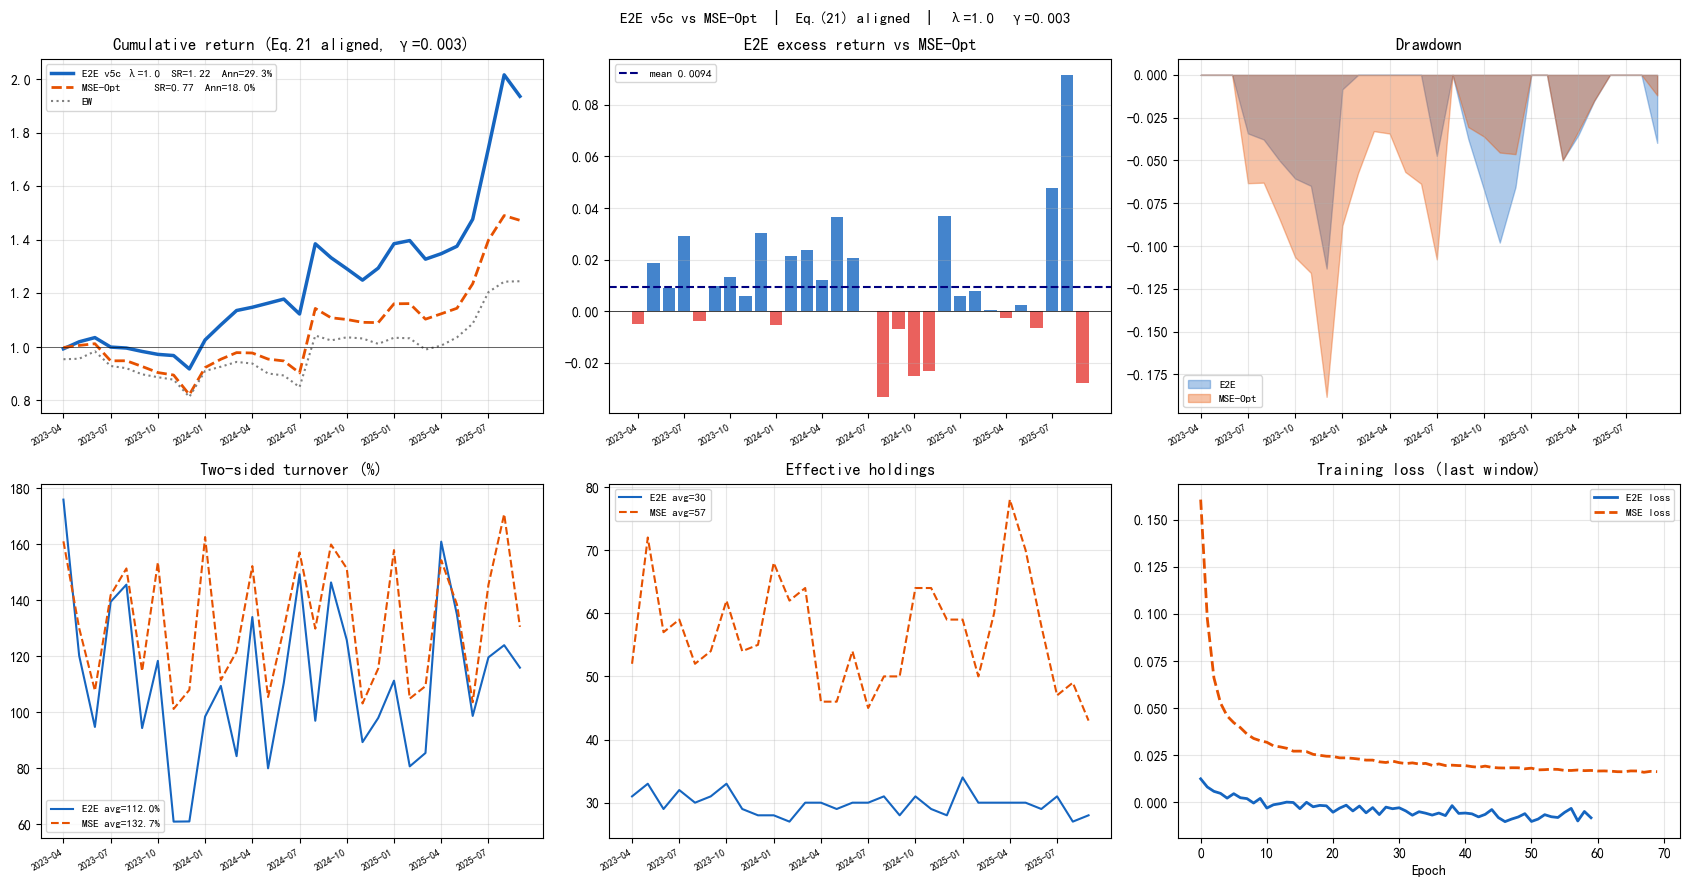

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


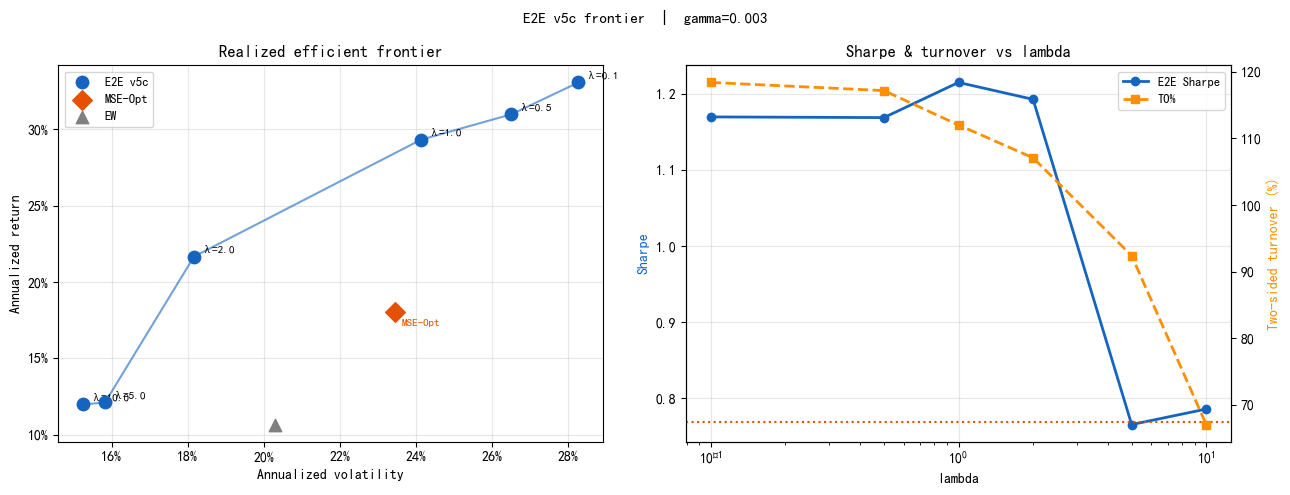

In [12]:
N_TEST  = len(r_e2e)
x       = np.arange(N_TEST)
dlabels = [d.strftime('%Y-%m') for d in res_e2e['dates']]
step    = max(1, N_TEST // 8)

cum_e2e = np.cumprod(1 + r_e2e)
cum_mse = np.cumprod(1 + r_mse)
cum_bch = np.cumprod(1 + r_bench)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

ax = axes[0, 0]
ax.plot(cum_e2e, color='#1565C0', lw=2.5,
        label=f"E2E v5c λ={LAMBDA}  SR={m_e2e['Sharpe']:.2f}  Ann={m_e2e['Ann_Ret']:.1%}")
ax.plot(cum_mse, color='#E65100', lw=2.0, ls='--',
        label=f"MSE-Opt      SR={m_mse['Sharpe']:.2f}  Ann={m_mse['Ann_Ret']:.1%}")
ax.plot(cum_bch, color='gray', lw=1.5, ls=':', label='EW')
ax.axhline(1, color='k', lw=0.4)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_title(f'Cumulative return (Eq.21 aligned, γ={GAMMA})')
ax.set_xticks(x[::step])
ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[0, 1]
excess = r_e2e - r_mse
ax.bar(x, excess, color=['#1565C0' if e > 0 else '#E53935' for e in excess], alpha=0.8)
ax.axhline(excess.mean(), color='navy', ls='--', lw=1.5, label=f'mean {excess.mean():.4f}')
ax.axhline(0, color='k', lw=0.5)
ax.legend(fontsize=8)
ax.set_title('E2E excess return vs MSE-Opt')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(x[::step])
ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

def dd_s(c):
    return (c / np.maximum.accumulate(c)) - 1

ax = axes[0, 2]
ax.fill_between(x, 0, dd_s(cum_e2e), color='#1565C0', alpha=0.35, label='E2E')
ax.fill_between(x, 0, dd_s(cum_mse), color='#E65100', alpha=0.35, label='MSE-Opt')
ax.set_title('Drawdown')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xticks(x[::step])
ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 0]
to_e2e = calc_turnover(res_e2e['weights'])
to_mse = calc_turnover(res_mse['weights'])
ax.plot(to_e2e * 100, color='#1565C0', lw=1.5, label=f'E2E avg={to_e2e.mean():.1%}')
ax.plot(to_mse * 100, color='#E65100', lw=1.5, ls='--', label=f'MSE avg={to_mse.mean():.1%}')
ax.set_title('Two-sided turnover (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xticks(x[::step])
ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 1]
eff_e2e = [(w > 0.001).sum() for w in res_e2e['weights']]
eff_mse = [(w > 0.001).sum() for w in res_mse['weights']]
ax.plot(eff_e2e, color='#1565C0', lw=1.5, label=f'E2E avg={np.mean(eff_e2e):.0f}')
ax.plot(eff_mse, color='#E65100', lw=1.5, ls='--', label=f'MSE avg={np.mean(eff_mse):.0f}')
ax.set_title('Effective holdings')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xticks(x[::step])
ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 2]
if res_e2e['loss_curves']:
    ax.plot(res_e2e['loss_curves'][-1], color='#1565C0', lw=2, label='E2E loss')
if res_mse['loss_curves']:
    ax.plot(res_mse['loss_curves'][-1], color='#E65100', lw=2, ls='--', label='MSE loss')
ax.set_title('Training loss (last window)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlabel('Epoch')

plt.suptitle(f'E2E v5c vs MSE-Opt  |  Eq.(21) aligned  |  λ={LAMBDA}  γ={GAMMA}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

if len(sweep_results) > 1:
    fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
    lam_vals = [l for l in LAMBDA_LIST if l in sweep_results]
    vols = [sweep_results[l]['metrics']['Ann_Vol'] for l in lam_vals]
    rets = [sweep_results[l]['metrics']['Ann_Ret'] for l in lam_vals]
    srs  = [sweep_results[l]['metrics']['Sharpe']  for l in lam_vals]
    tos  = [sweep_results[l]['metrics']['AvgTO']   for l in lam_vals]

    ax = axes2[0]
    ax.scatter(vols, rets, color='#1565C0', s=80, zorder=4, label='E2E v5c')
    ax.plot(vols, rets, color='#1565C0', lw=1.5, alpha=0.6)
    for l, v, r in zip(lam_vals, vols, rets):
        ax.annotate(f'λ={l}', (v, r), textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax.scatter([m_mse['Ann_Vol']], [m_mse['Ann_Ret']], color='#E65100', s=100, marker='D', label='MSE-Opt')
    ax.annotate('MSE-Opt', (m_mse['Ann_Vol'], m_mse['Ann_Ret']),
                textcoords='offset points', xytext=(5, -10), fontsize=8, color='#E65100')
    ax.scatter([m_bench['Ann_Vol']], [m_bench['Ann_Ret']], color='gray', s=80, marker='^', label='EW')
    ax.set_xlabel('Annualized volatility')
    ax.set_ylabel('Annualized return')
    ax.set_title('Realized efficient frontier')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    ax = axes2[1]
    ln1 = ax.plot(lam_vals, srs, color='#1565C0', lw=2, marker='o', label='E2E Sharpe')
    ax2b = ax.twinx()
    ln2 = ax2b.plot(lam_vals, [t * 100 for t in tos], color='#FF8F00', lw=2, ls='--', marker='s', label='TO%')
    ax.axhline(m_mse['Sharpe'], color='#E65100', ls=':', lw=1.5, label=f'MSE SR={m_mse["Sharpe"]:.2f}')
    ax.set_xlabel('lambda')
    ax.set_ylabel('Sharpe', color='#1565C0')
    ax2b.set_ylabel('Two-sided turnover (%)', color='#FF8F00')
    ax.set_title('Sharpe & turnover vs lambda')
    lns = ln1 + ln2
    ax.legend(lns, [l.get_label() for l in lns], fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xscale('log')

    plt.suptitle(f'E2E v5c frontier  |  gamma={GAMMA}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
